In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive')

!mkdir -p olist-customer-intelligence/{data/raw,data/processed,notebooks,sql,src,models,reports,app/pages,docs}
os.chdir('/content/drive/MyDrive/olist-customer-intelligence')
!touch src/__init__.py
print("Now in:", os.getcwd())

Now in: /content/drive/MyDrive/olist-customer-intelligence


In [4]:
# install kaggle tool + upload your key
!pip install -q kaggle

from google.colab import files
print("When the button appears, upload your kaggle.json:")
files.upload()

import os
os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print("\n✅ Kaggle key installed.")

When the button appears, upload your kaggle.json:


Saving kaggle.json to kaggle (1).json

✅ Kaggle key installed.


In [5]:
!kaggle datasets download -d olistbr/brazilian-ecommerce -p data/raw --unzip
!ls -lh data/raw

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:00<00:00, 143MB/s]

total 121M
-rw------- 1 root root 8.7M Jun 25 16:40 olist_customers_dataset.csv
-rw------- 1 root root  59M Jun 25 16:40 olist_geolocation_dataset.csv
-rw------- 1 root root  15M Jun 25 16:40 olist_order_items_dataset.csv
-rw------- 1 root root 5.6M Jun 25 16:40 olist_order_payments_dataset.csv
-rw------- 1 root root  14M Jun 25 16:40 olist_order_reviews_dataset.csv
-rw------- 1 root root  17M Jun 25 16:40 olist_orders_dataset.csv
-rw------- 1 root root 2.3M Jun 25 16:40 olist_products_dataset.csv
-rw------- 1 root root 171K Jun 25 16:40 olist_sellers_dataset.csv
-rw------- 1 root root 2.6K Jun 25 16:40 product_category_name_translation.csv


In [6]:
%%writefile src/data_loader.py
"""DuckDB analytical layer for Olist e-commerce data."""
from pathlib import Path
import duckdb

RAW_DIR = Path("data/raw")
DB_PATH = Path("data/processed/olist.duckdb")

TABLES = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "order_payments": "olist_order_payments_dataset.csv",
    "order_reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}


def get_connection(read_only: bool = False) -> duckdb.DuckDBPyConnection:
    """Return a connection to the Olist DuckDB database."""
    DB_PATH.parent.mkdir(parents=True, exist_ok=True)
    return duckdb.connect(str(DB_PATH), read_only=read_only)


def build_database(overwrite: bool = True) -> None:
    """Load all 9 raw CSVs into DuckDB as native tables."""
    con = get_connection()
    for table, filename in TABLES.items():
        csv_path = RAW_DIR / filename
        if not csv_path.exists():
            raise FileNotFoundError(f"Missing raw CSV: {csv_path}")
        if overwrite:
            con.execute(f"DROP TABLE IF EXISTS {table}")
        con.execute(
            f"CREATE TABLE {table} AS "
            f"SELECT * FROM read_csv_auto('{csv_path}', header=True)"
        )
        n = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
        print(f"  loaded {table:24s} {n:>8,} rows")
    con.close()


def run_query(sql: str, read_only: bool = True):
    """Execute a SQL string and return a pandas DataFrame."""
    con = get_connection(read_only=read_only)
    try:
        return con.execute(sql).df()
    finally:
        con.close()

Writing src/data_loader.py


In [7]:
!pip install -q duckdb

In [8]:
import sys
sys.path.append(".")
from src.data_loader import build_database, run_query
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

build_database()

  loaded customers                  99,441 rows
  loaded geolocation              1,000,163 rows
  loaded order_items               112,650 rows
  loaded order_payments            103,886 rows
  loaded order_reviews              99,224 rows
  loaded orders                     99,441 rows
  loaded products                   32,951 rows
  loaded sellers                     3,095 rows
  loaded category_translation           71 rows


In [9]:
schema = run_query("""
    SELECT table_name, column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'main'
    ORDER BY table_name, ordinal_position
""")
for t in schema.table_name.unique():
    print(f"\n=== {t} ===")
    print(schema[schema.table_name == t][["column_name", "data_type"]].to_string(index=False))


=== category_translation ===
                  column_name data_type
        product_category_name   VARCHAR
product_category_name_english   VARCHAR

=== customers ===
             column_name data_type
             customer_id   VARCHAR
      customer_unique_id   VARCHAR
customer_zip_code_prefix   VARCHAR
           customer_city   VARCHAR
          customer_state   VARCHAR

=== geolocation ===
                column_name data_type
geolocation_zip_code_prefix   VARCHAR
            geolocation_lat    DOUBLE
            geolocation_lng    DOUBLE
           geolocation_city   VARCHAR
          geolocation_state   VARCHAR

=== order_items ===
        column_name data_type
           order_id   VARCHAR
      order_item_id    BIGINT
         product_id   VARCHAR
          seller_id   VARCHAR
shipping_limit_date TIMESTAMP
              price    DOUBLE
      freight_value    DOUBLE

=== order_payments ===
         column_name data_type
            order_id   VARCHAR
  payment_sequential    B

In [10]:
run_query("""
    SELECT order_status,
           COUNT(*) AS n_orders,
           MIN(order_purchase_timestamp) AS first_order,
           MAX(order_purchase_timestamp) AS last_order
    FROM orders
    GROUP BY order_status
    ORDER BY n_orders DESC
""")

,order_status,n_orders,first_order,last_order
0,delivered,96478,2016-09-15 12:16:38,2018-08-29 15:00:37
1,shipped,1107,2016-09-04 21:15:19,2018-09-03 09:06:57
2,canceled,625,2016-09-05 00:15:34,2018-10-17 17:30:18
3,unavailable,609,2016-10-05 14:16:28,2018-08-21 12:21:00
4,invoiced,314,2016-10-04 13:02:10,2018-08-14 18:45:08
5,processing,301,2016-10-05 22:44:13,2018-07-23 18:03:03
6,created,5,2017-11-06 13:12:34,2018-02-09 17:21:04
7,approved,2,2017-02-06 20:18:17,2017-04-25 01:25:34


In [12]:
customer_orders_sql = """
    SELECT
        c.customer_unique_id,
        o.order_id,
        o.order_purchase_timestamp,
        o.order_status,
        COUNT(oi.order_item_id)                          AS n_items,
        SUM(oi.price)                                    AS items_value,
        SUM(oi.freight_value)                            AS freight_value,
        SUM(oi.price + oi.freight_value)                 AS order_value
    FROM orders o
    JOIN customers c        ON o.customer_id = c.customer_id
    LEFT JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1, 2, 3, 4
"""
df = run_query(customer_orders_sql)
print(df.shape)
df.head(10)

(96478, 8)


,customer_unique_id,order_id,order_purchase_timestamp,order_status,n_items,items_value,freight_value,order_value
0,3818d81c6709e39d06b2738a8d3a2474,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,delivered,1,199.00,17.87,216.87
1,af861d436cfc08b2c2ddefd0ba074622,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35,delivered,1,12.99,12.79,25.78
2,85c835d128beae5b4ce8602c491bf385,00048cc3ae777c65dbb7d2a0634bc1ea,2017-05-15 21:42:34,delivered,1,21.90,12.69,34.59
3,fda4476abb6307ab3c415b7e6d026526,000576fe39319847cbb9d288c5617fa6,2018-07-04 12:08:27,delivered,1,810.00,70.75,880.75
4,639d23421f5517f69d0c3d6e6564cf0e,0005a1a1728c9d785b8e2b08b904576c,2018-03-19 18:40:33,delivered,1,145.95,11.65,157.60
5,0782c41380992a5a533489063df0eef6,0005f50442cb953dcd1d21e1fb923495,2018-07-02 13:59:39,delivered,1,53.99,11.40,65.39
6,107e6259485efac66428a56f10801f4f,00061f2a7bc09da83e415a52dc8a4af1,2018-03-24 22:16:10,delivered,1,59.99,8.88,68.87
7,3fb97204945ca0c01bcf3eee6031c5f1,00063b381e2406b52ad429470734ebd5,2018-07-27 17:21:27,delivered,1,45.00,12.98,57.98
8,4987996ddcd0ddb20740fdce7c2bfbb1,0009792311464db532ff765bf7b182ae,2018-08-14 20:43:09,delivered,1,99.90,27.65,127.55
9,6062db572f3ef38b7a8ff4307abbfad3,0009c9a17f916a706d71784483a5d643,2018-04-25 09:10:41,delivered,1,639.00,11.34,650.34


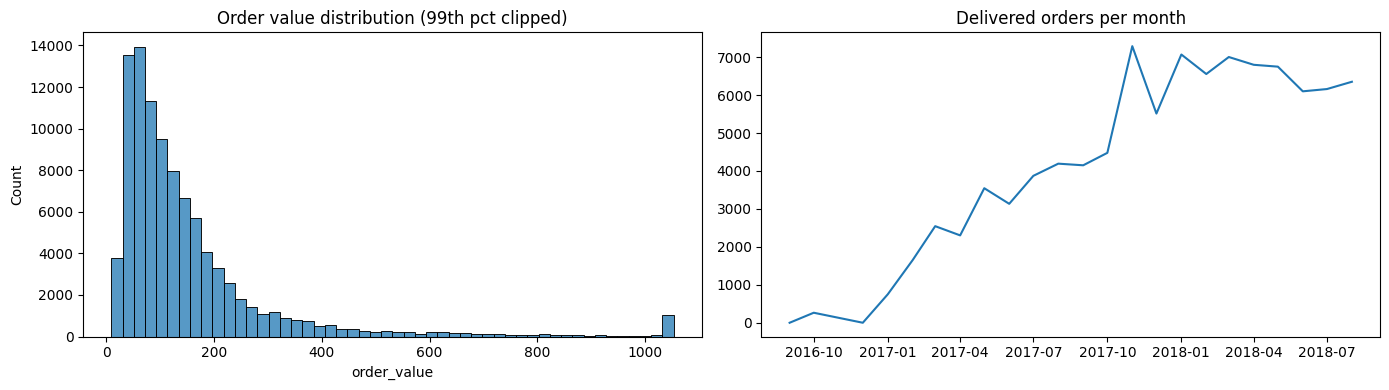

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["order_value"].clip(upper=df["order_value"].quantile(0.99)),
             bins=50, ax=axes[0])
axes[0].set_title("Order value distribution (99th pct clipped)")

monthly = run_query("""
    SELECT date_trunc('month', order_purchase_timestamp) AS month,
           COUNT(*) AS orders
    FROM orders WHERE order_status='delivered'
    GROUP BY 1 ORDER BY 1
""")
axes[1].plot(monthly["month"], monthly["orders"])
axes[1].set_title("Delivered orders per month")
plt.tight_layout()

In [14]:
run_query("""
    SELECT
        COUNT(DISTINCT customer_unique_id) AS unique_people,
        COUNT(DISTINCT customer_id)        AS customer_id_rows,
        COUNT(*)                           AS total_customer_rows
    FROM customers
""")

,unique_people,customer_id_rows,total_customer_rows
0,96096,99441,99441


In [15]:
%%writefile sql/01_customer_orders.sql
-- 01_customer_orders.sql
-- Order-grain spine: one row per delivered order with customer, value, timing.
-- Joins: orders -> customers (customer_unique_id), orders -> order_items.
SELECT
    c.customer_unique_id,
    o.order_id,
    o.order_purchase_timestamp,
    o.order_status,
    COUNT(oi.order_item_id)              AS n_items,
    SUM(oi.price)                        AS items_value,
    SUM(oi.freight_value)                AS freight_value,
    SUM(oi.price + oi.freight_value)     AS order_value
FROM orders o
JOIN customers c         ON o.customer_id = c.customer_id
LEFT JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY 1, 2, 3, 4;

Writing sql/01_customer_orders.sql


## Summary — EDA & SQL Setup

**Goal:** Build the DuckDB analytical layer over the 9 raw Olist CSVs,
understand the schema, run first multi-table joins, and lock business questions.

**What was done**
- Loaded all 9 Olist CSVs into a native DuckDB database (`data/processed/olist.duckdb`)
  via `src/data_loader.py`.
- Inspected schema across all tables and documented join keys.
- Ran order-status + date-range checks and the first order-grain join
  (saved as `sql/01_customer_orders.sql`).

**Key data model facts**
- `customer_unique_id` = the real person; `customer_id` = per-order identifier.
  Always aggregate to `customer_unique_id` for customer-level analysis.
- Join spine: orders → customers (customer_id), orders → order_items (order_id),
  products → category_translation (PT→EN).

**Key findings**
- 99,441 customer rows map to only 96,096 unique people.
- 96,478 delivered orders (the dominant status); small counts for shipped /
  canceled / unavailable / etc. We filter to `delivered` everywhere.
- Analysis window: 2016-09-15 → 2018-08-29. Snapshot/anchor date = 2018-08-29
  (used for recency).

**The dataset's defining trait**
- ~96% of customers order exactly once. This is NOT a churn dataset —
  it's a one-time-buyer dataset. This single fact reshapes RFM, CLV, and the
  entire business framing downstream.

**Deliverables created**
- `src/data_loader.py`, `data/processed/olist.duckdb`
- `sql/01_customer_orders.sql`
- 4 locked business questions (value segments / segment prediction /
  causal delivery→retention / budget allocation).